# Visual Product Recommendation System
### Image-based similarity search using Deep Learning, Transfer Learning & Siamese Networks

This notebook builds an **image-based recommendation engine** for e-commerce products using the
[Fashion Product Images Dataset](https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset).

**Pipeline**
1. Download & subset the dataset (5–8 categories, ~200–300 images each)
2. Preprocess images (resize 224×224, ImageNet normalization)
3. Extract baseline embeddings with a pretrained CNN (ResNet50)
4. Baseline retrieval with cosine similarity + FAISS
5. Transfer learning — fine-tune the last layers on the subset
6. Siamese Network trained with triplet loss for a similarity-optimized embedding space
7. Evaluation — Precision@K, Recall@K, qualitative comparison, inference speed
8. Export artifacts + a Streamlit UI (`app.py`) for interactive search

> Designed to run top-to-bottom on **Google Colab** (GPU runtime recommended: `Runtime > Change runtime type > GPU`).


## 0. Setup — install dependencies

In [1]:
!pip install -q tensorflow faiss-cpu opencv-python-headless scikit-learn \
    kagglehub streamlit pyngrok matplotlib pillow tqdm
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 26.5 MB/s eta 0:00:00
Dependencies installed.


In [2]:
import os, json, random, time, shutil, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset download (kagglehub)




In [3]:
import kagglehub

DATA_DIR = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")
print("Dataset downloaded to:", DATA_DIR)

!find {DATA_DIR} -maxdepth 2

100%|██████████| 23.1G/23.1G [04:09<00:00, 99.2MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset/images
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset/styles.csv
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset/fashion-dataset
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset/styles
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset/images.csv


## 2. Dataset subsetting

The full dataset has 44k+ products. For efficient experimentation we build a **balanced subset**:
- Select **5–8 categories** (`articleType`, e.g. Shirts, Tshirts, Casual Shoes, Sports Shoes, Dresses, Handbags)
- Sample **~200–300 images per category** (≈1500–2500 images total)


In [4]:
# Locate styles.csv and the images directory (path can vary slightly by dataset version)
possible_csv = glob.glob(os.path.join(DATA_DIR, '**', 'styles.csv'), recursive=True)
CSV_PATH = possible_csv[0]
possible_img_dir = glob.glob(os.path.join(DATA_DIR, '**', 'images'), recursive=True)
IMAGES_DIR = possible_img_dir[0]
print("styles.csv:", CSV_PATH)
print("images dir:", IMAGES_DIR)

df = pd.read_csv(CSV_PATH, on_bad_lines='skip')
df['image_path'] = df['id'].astype(str).apply(lambda x: os.path.join(IMAGES_DIR, f"{x}.jpg"))
df = df[df['image_path'].apply(os.path.exists)]
print(df.shape)
df['articleType'].value_counts().head(20)

styles.csv: /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset/styles.csv
images dir: /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1/fashion-dataset/images
(44419, 11)


,count
articleType,
Tshirts,7066
Shirts,3215
Casual Shoes,2845
Watches,2542
Sports Shoes,2036
Kurtas,1844
Tops,1762
Handbags,1759
Heels,1323


In [5]:
# ---- Configure the subset ----
SELECTED_CATEGORIES = ['Tshirts', 'Shirts', 'Casual Shoes', 'Sports Shoes', 'Dresses', 'Handbags', 'Watches']
SAMPLES_PER_CATEGORY = 250

subset_frames = []
for cat in SELECTED_CATEGORIES:
    cat_df = df[df['articleType'] == cat]
    n = min(SAMPLES_PER_CATEGORY, len(cat_df))
    subset_frames.append(cat_df.sample(n=n, random_state=SEED))

subset_df = pd.concat(subset_frames).reset_index(drop=True)
print("Subset size:", len(subset_df))
subset_df['articleType'].value_counts()

Subset size: 1750


,count
articleType,
Tshirts,250
Shirts,250
Casual Shoes,250
Sports Shoes,250
Dresses,250
Handbags,250
Watches,250


In [6]:
SUBSET_DIR = '/content/subset_images'
os.makedirs(SUBSET_DIR, exist_ok=True)

for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Copying subset images"):
    dst = os.path.join(SUBSET_DIR, os.path.basename(row['image_path']))
    if not os.path.exists(dst):
        shutil.copy(row['image_path'], dst)

subset_df['local_path'] = subset_df['image_path'].apply(
    lambda p: os.path.join(SUBSET_DIR, os.path.basename(p)))
subset_df.to_csv('/content/subset_metadata.csv', index=False)
print("Subset ready at:", SUBSET_DIR)

Copying subset images:   0%|          | 0/1750 [00:00<?, ?it/s]

Subset ready at: /content/subset_images


## 3. Preprocessing

Every image is resized to **224×224** and normalized using ImageNet statistics
(handled by `resnet50.preprocess_input`, matching how the pretrained backbone was trained).


Preprocessed shape: (224, 224, 3) | dtype: float32


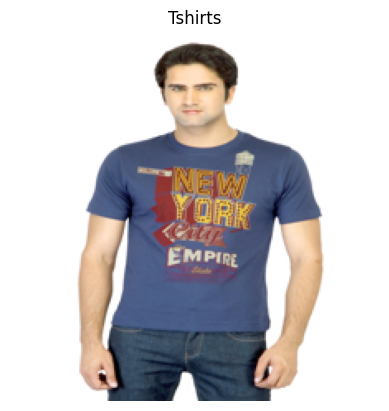

In [7]:
IMG_SIZE = 224

def load_and_preprocess(path, size=IMG_SIZE):
    """Load an image from disk, resize to (size,size), return ImageNet-normalized array."""
    img = cv2.imread(path)
    if img is None:
        img = np.array(Image.open(path).convert('RGB'))
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    arr = img.astype('float32')
    arr = preprocess_input(arr)  # ImageNet mean/std normalization for ResNet50
    return arr

def load_raw(path, size=IMG_SIZE):
    """Load an image for display purposes only (no normalization)."""
    img = Image.open(path).convert('RGB').resize((size, size))
    return np.array(img)

# quick sanity check
sample_path = subset_df['local_path'].iloc[0]
test_arr = load_and_preprocess(sample_path)
print("Preprocessed shape:", test_arr.shape, "| dtype:", test_arr.dtype)
plt.imshow(load_raw(sample_path)); plt.axis('off'); plt.title(subset_df['articleType'].iloc[0]); plt.show()

## 4. Baseline feature extraction (pretrained ResNet50)

We remove the classification head (`include_top=False`) and use **global average pooling**
to obtain a single 2048-dim embedding vector per image.


In [8]:
def build_feature_extractor():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    return Model(inputs=base.input, outputs=base.output, name='resnet50_embedding')

baseline_model = build_feature_extractor()
baseline_model.trainable = False
baseline_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50_embedding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
def extract_embeddings(model, paths, batch_size=32):
    """Extract embeddings for a list of image paths using the given Keras model."""
    embeddings = []
    for i in tqdm(range(0, len(paths), batch_size), desc="Extracting embeddings"):
        batch_paths = paths[i:i+batch_size]
        batch = np.stack([load_and_preprocess(p) for p in batch_paths])
        emb = model.predict(batch, verbose=0)
        embeddings.append(emb)
    return np.vstack(embeddings)

all_paths = subset_df['local_path'].tolist()
baseline_embeddings = extract_embeddings(baseline_model, all_paths)
np.save('/content/baseline_embeddings.npy', baseline_embeddings)
print("Baseline embeddings shape:", baseline_embeddings.shape)

Extracting embeddings:   0%|          | 0/55 [00:00<?, ?it/s]

Baseline embeddings shape: (1750, 2048)


## 5. Baseline retrieval — cosine similarity top-K

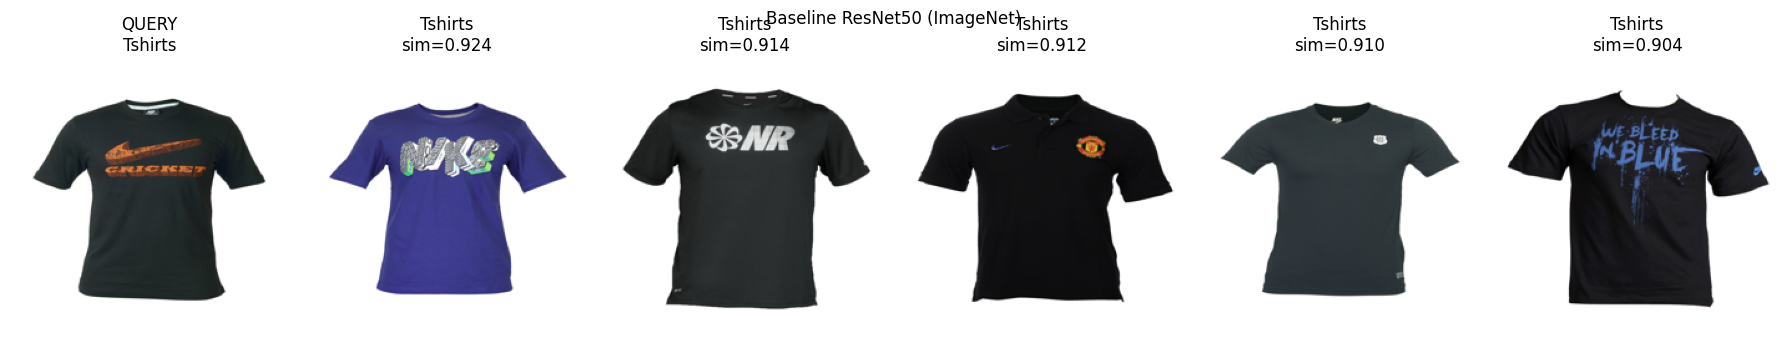

In [10]:
def retrieve_top_k(query_embedding, embedding_matrix, k=5, exclude_idx=None):
    """Return indices and scores of the top-k most similar embeddings."""
    sims = cosine_similarity(query_embedding.reshape(1, -1), embedding_matrix)[0]
    if exclude_idx is not None:
        sims[exclude_idx] = -1
    top_idx = np.argsort(sims)[::-1][:k]
    return top_idx, sims[top_idx]

def show_results(query_idx, top_idx, scores, paths, labels, title="Results"):
    n = len(top_idx) + 1
    plt.figure(figsize=(3*n, 3.5))
    plt.subplot(1, n, 1)
    plt.imshow(load_raw(paths[query_idx])); plt.title(f"QUERY\n{labels[query_idx]}"); plt.axis('off')
    for i, (idx, score) in enumerate(zip(top_idx, scores)):
        plt.subplot(1, n, i+2)
        plt.imshow(load_raw(paths[idx]))
        plt.title(f"{labels[idx]}\nsim={score:.3f}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

labels = subset_df['articleType'].tolist()
query_idx = random.randint(0, len(all_paths)-1)
top_idx, scores = retrieve_top_k(baseline_embeddings[query_idx], baseline_embeddings, k=5, exclude_idx=query_idx)
show_results(query_idx, top_idx, scores, all_paths, labels, title="Baseline ResNet50 (ImageNet)")

## 6. Fast similarity search with FAISS

For large catalogs, brute-force cosine similarity doesn't scale. **FAISS** builds an index
for fast approximate/exact nearest-neighbor search over the embedding space.


In [11]:
!pip install faiss-cpu
import faiss
print("FAISS:", faiss.__version__)

FAISS: 1.14.3


FAISS query time: 8.22 ms


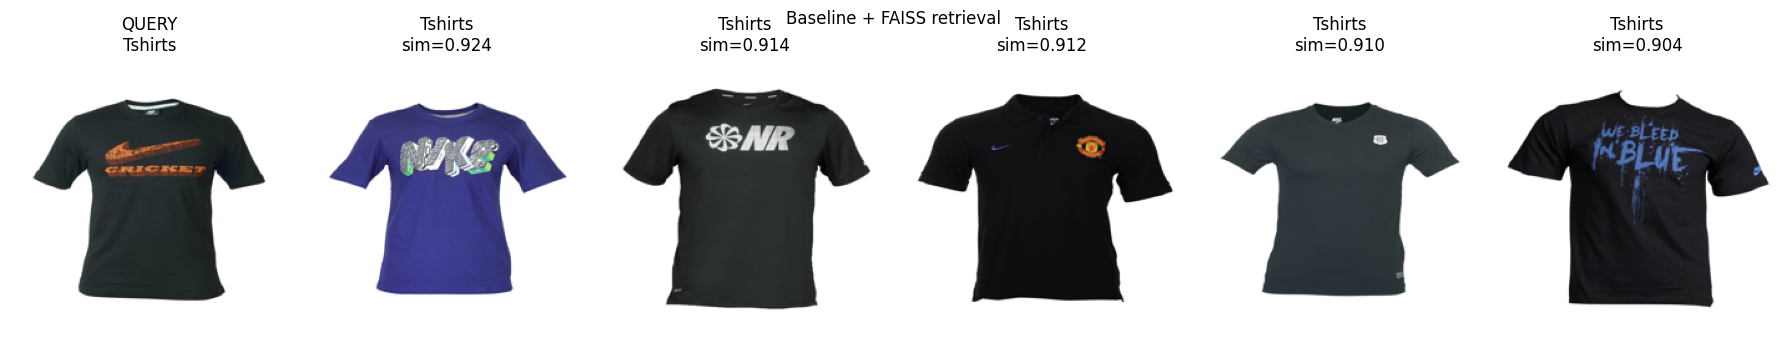

In [12]:
# import faiss

def build_faiss_index(embeddings):
    """L2-normalize embeddings and build an Inner-Product index (== cosine similarity on unit vectors)."""
    norm_emb = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-10)
    index = faiss.IndexFlatIP(norm_emb.shape[1])
    index.add(norm_emb.astype('float32'))
    return index, norm_emb

def faiss_search(index, norm_embeddings, query_idx, k=5):
    query_vec = norm_embeddings[query_idx:query_idx+1].astype('float32')
    scores, idx = index.search(query_vec, k+1)  # +1 because the query itself will match
    mask = idx[0] != query_idx
    return idx[0][mask][:k], scores[0][mask][:k]

faiss_index, norm_baseline_emb = build_faiss_index(baseline_embeddings)
t0 = time.time()
top_idx_f, scores_f = faiss_search(faiss_index, norm_baseline_emb, query_idx, k=5)
print(f"FAISS query time: {(time.time()-t0)*1000:.2f} ms")
show_results(query_idx, top_idx_f, scores_f, all_paths, labels, title="Baseline + FAISS retrieval")

## 7. Transfer learning — fine-tune the last layers

We freeze most of ResNet50 and fine-tune only the top layers plus a new classification head
on our subset's categories. This adapts the feature space to fashion-specific visual cues
(texture, silhouette, pattern) that ImageNet training doesn't emphasize.


In [13]:
le_categories = sorted(subset_df['articleType'].unique())
cat_to_idx = {c: i for i, c in enumerate(le_categories)}
subset_df['label'] = subset_df['articleType'].map(cat_to_idx)
NUM_CLASSES = len(le_categories)
print("Classes:", le_categories)

train_df, val_df = train_test_split(subset_df, test_size=0.15, stratify=subset_df['label'], random_state=SEED)
print("Train:", len(train_df), "Val:", len(val_df))

Classes: ['Casual Shoes', 'Dresses', 'Handbags', 'Shirts', 'Sports Shoes', 'Tshirts', 'Watches']
Train: 1487 Val: 263


In [14]:
def make_dataset(df_split, batch_size=32, shuffle=True):
    paths = df_split['local_path'].tolist()
    labels_ = df_split['label'].tolist()

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = preprocess_input(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels_))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)

In [15]:
def build_transfer_model(num_classes, fine_tune_layers=15):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = True
    # Freeze all layers except the last `fine_tune_layers`
    for layer in base.layers[:-fine_tune_layers]:
        layer.trainable = False

    x = base.output
    x = layers.Dense(256, activation='relu', name='embedding_dense')(x)  # this becomes our new embedding layer
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='classifier')(x)

    model = Model(inputs=base.input, outputs=outputs, name='resnet50_transfer')
    embedding_layer_name = 'embedding_dense'
    return model, embedding_layer_name

transfer_model, EMB_LAYER = build_transfer_model(NUM_CLASSES, fine_tune_layers=15)
transfer_model.compile(optimizer=Adam(learning_rate=1e-4),
                        loss='sparse_categorical_crossentropy', metrics=['accuracy'])

trainable_count = sum(1 for l in transfer_model.layers if l.trainable)
print(f"Trainable layers: {trainable_count} / {len(transfer_model.layers)}")

Trainable layers: 18 / 179


Epoch 1/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 72s 872ms/step - accuracy: 0.7915 - loss: 0.5995 - val_accuracy: 0.9049 - val_loss: 0.3066
Epoch 2/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 555ms/step - accuracy: 0.9623 - loss: 0.1093 - val_accuracy: 0.9354 - val_loss: 0.1899
Epoch 3/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 573ms/step - accuracy: 0.9792 - loss: 0.0611 - val_accuracy: 0.9430 - val_loss: 0.1926
Epoch 4/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 505ms/step - accuracy: 0.9913 - loss: 0.0323 - val_accuracy: 0.9430 - val_loss: 0.1903
Epoch 5/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 518ms/step - accuracy: 0.9960 - loss: 0.0167 - val_accuracy: 0.9430 - val_loss: 0.2218
Epoch 6/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 43s 561ms/step - accuracy: 0.9966 - loss: 0.0151 - val_accuracy: 0.9506 - val_loss: 0.2274
Epoch 7/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 550ms/step - accuracy: 0.9966 - loss: 0.0115 - val_accuracy: 0.9354 - val_loss: 0.2665
Epoch 8/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 487ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.

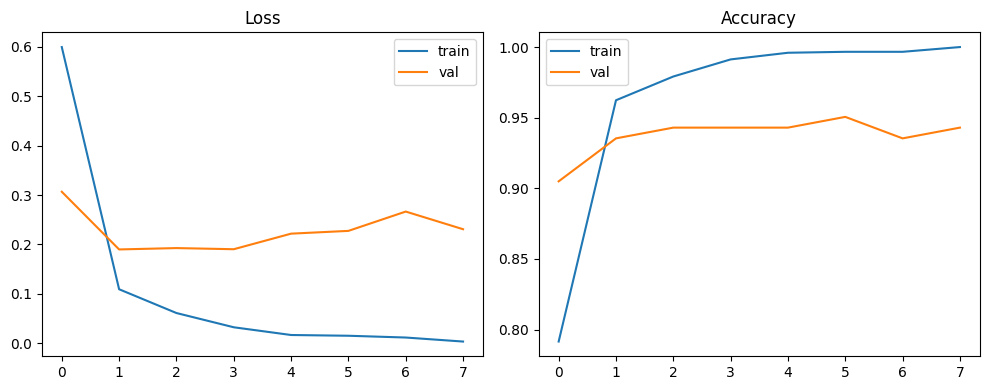

In [16]:
EPOCHS = 8
history = transfer_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(history.history['loss'], label='train'); plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.subplot(1,2,2); plt.plot(history.history['accuracy'], label='train'); plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

Extracting embeddings:   0%|          | 0/55 [00:00<?, ?it/s]

Transfer-learned embeddings shape: (1750, 256)


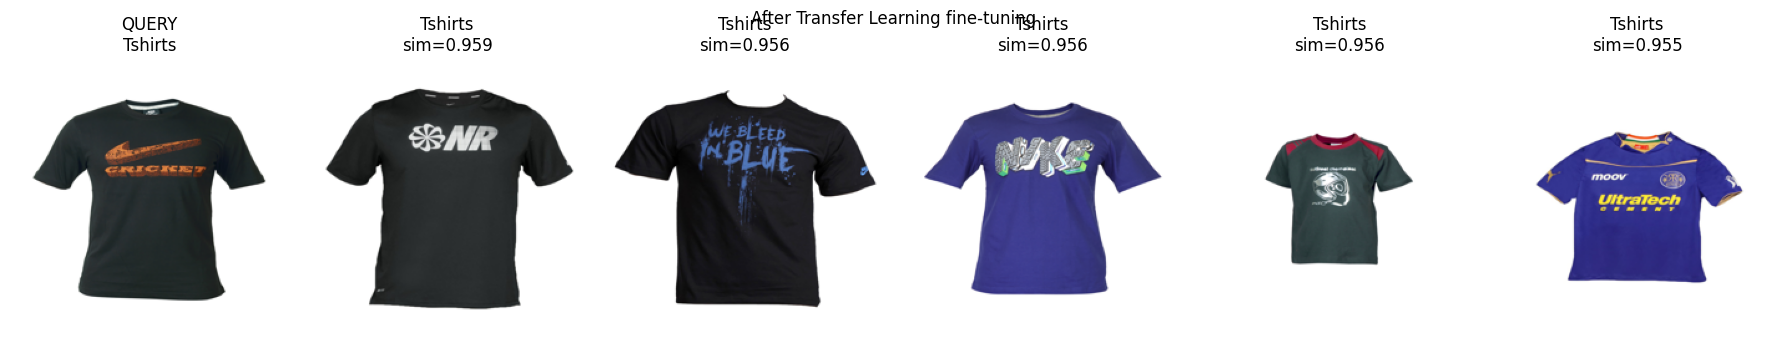

In [17]:
# Build an embedding-only model from the fine-tuned network (output = the 256-dim Dense layer, pre-softmax)
transfer_embedding_model = Model(inputs=transfer_model.input,
                                  outputs=transfer_model.get_layer(EMB_LAYER).output,
                                  name='transfer_embedding')

transfer_embeddings = extract_embeddings(transfer_embedding_model, all_paths)
np.save('/content/transfer_embeddings.npy', transfer_embeddings)
print("Transfer-learned embeddings shape:", transfer_embeddings.shape)

top_idx_t, scores_t = retrieve_top_k(transfer_embeddings[query_idx], transfer_embeddings, k=5, exclude_idx=query_idx)
show_results(query_idx, top_idx_t, scores_t, all_paths, labels, title="After Transfer Learning fine-tuning")

## 8. Siamese Network with triplet loss (core enhancement)

The transfer-learned model is optimized for *classification*, not for *similarity ranking*.
A **Siamese network** trained with **triplet loss** directly shapes the embedding space so that:

- distance(Anchor, Positive) — same category — is **small**
- distance(Anchor, Negative) — different category — is **large**

We build triplets `(Anchor, Positive, Negative)` from the subset, sharing one embedding
sub-network (initialized from the fine-tuned backbone) across all three inputs.


In [18]:
def build_triplets(df_split, n_triplets):
    """Sample (anchor, positive, negative) file-path triplets based on category labels."""
    triplets = []
    grouped = df_split.groupby('articleType')['local_path'].apply(list).to_dict()
    categories_ = list(grouped.keys())

    for _ in range(n_triplets):
        pos_cat = random.choice(categories_)
        neg_cat = random.choice([c for c in categories_ if c != pos_cat])
        if len(grouped[pos_cat]) < 2:
            continue
        anchor, positive = random.sample(grouped[pos_cat], 2)
        negative = random.choice(grouped[neg_cat])
        triplets.append((anchor, positive, negative))
    return triplets

N_TRIPLETS_TRAIN = 4000
N_TRIPLETS_VAL = 600
train_triplets = build_triplets(train_df, N_TRIPLETS_TRAIN)
val_triplets = build_triplets(val_df, N_TRIPLETS_VAL)
print("Train triplets:", len(train_triplets), "| Val triplets:", len(val_triplets))
print("Example:", train_triplets[0])

Train triplets: 4000 | Val triplets: 600
Example: ('/content/subset_images/41752.jpg', '/content/subset_images/50194.jpg', '/content/subset_images/57035.jpg')


In [19]:
def triplet_generator(triplets, batch_size=16):
    def _load3(a, p, n):
        def _one(path):
            img = tf.io.read_file(path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
            return preprocess_input(img)
        return (_one(a), _one(p), _one(n)), tf.constant(0.0)  # dummy label, loss uses embeddings directly

    anchors = [t[0] for t in triplets]
    positives = [t[1] for t in triplets]
    negatives = [t[2] for t in triplets]

    ds = tf.data.Dataset.from_tensor_slices((anchors, positives, negatives))
    ds = ds.map(_load3, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_triplet_ds = triplet_generator(train_triplets)
val_triplet_ds = triplet_generator(val_triplets)

In [20]:
# A plain `layers.Lambda(lambda t: ...)` stores a pickled Python function inside the
# saved model, which Keras 3 refuses to deserialize by default (arbitrary code execution
# risk). Using a small registered custom Layer instead avoids that entirely and loads
# safely in any process (e.g. the separate Streamlit process for the UI).
@tf.keras.utils.register_keras_serializable(package='custom', name='L2Normalize')
class L2Normalize(layers.Layer):
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

def build_embedding_subnet(embedding_dim=128, fine_tune_layers=15):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = True
    for layer in base.layers[:-fine_tune_layers]:
        layer.trainable = False
    x = layers.Dense(256, activation='relu')(base.output)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(embedding_dim)(x)
    x = L2Normalize(name='l2_norm')(x)  # unit-norm embeddings
    return Model(inputs=base.input, outputs=x, name='siamese_embedding')

EMBEDDING_DIM = 128
embedding_subnet = build_embedding_subnet(embedding_dim=EMBEDDING_DIM, fine_tune_layers=15)

anchor_in = Input((IMG_SIZE, IMG_SIZE, 3), name='anchor')
positive_in = Input((IMG_SIZE, IMG_SIZE, 3), name='positive')
negative_in = Input((IMG_SIZE, IMG_SIZE, 3), name='negative')

anchor_emb = embedding_subnet(anchor_in)
positive_emb = embedding_subnet(positive_in)
negative_emb = embedding_subnet(negative_in)

merged = layers.Concatenate(axis=1)([anchor_emb, positive_emb, negative_emb])
siamese_model = Model(inputs=[anchor_in, positive_in, negative_in], outputs=merged, name='siamese_triplet_model')
siamese_model.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_embedding   │ (None, 128)       │ 24,145,152 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ siamese_embeddin… │
│ (Concatenate)       │                   │            │ siamese_embeddin… │
│                     │                   │            │ siamese_embeddin… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,145,152 (92.11 MB)

 Trainable params: 6,077,824 (23.19 MB)

 Non-trainable params: 18,067,328 (68.92 MB)

In [21]:
def triplet_loss(margin=0.3):
    def loss_fn(y_true, y_pred):
        # y_pred is the concatenation [anchor_emb | positive_emb | negative_emb], each of size EMBEDDING_DIM
        anchor, positive, negative = tf.split(y_pred, num_or_size_splits=3, axis=1)
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
        basic_loss = pos_dist - neg_dist + margin
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))
    return loss_fn

siamese_model.compile(optimizer=Adam(learning_rate=1e-4), loss=triplet_loss(margin=0.3))

In [ ]:
SIAMESE_EPOCHS = 6

def reshape_for_training(ds):
    # ds yields ((a,p,n), dummy_label) -> convert to (dict_of_inputs, dummy_label) for the multi-input Model
    return ds.map(lambda inputs, y: ({'anchor': inputs[0], 'positive': inputs[1], 'negative': inputs[2]}, y))

train_triplet_ds_named = reshape_for_training(train_triplet_ds)
val_triplet_ds_named = reshape_for_training(val_triplet_ds)

siamese_history = siamese_model.fit(train_triplet_ds_named, validation_data=val_triplet_ds_named, epochs=SIAMESE_EPOCHS)

plt.plot(siamese_history.history['loss'], label='train')
plt.plot(siamese_history.history['val_loss'], label='val')
plt.title('Triplet loss'); plt.legend(); plt.show()

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 252s 840ms/step - loss: 0.0330 - val_loss: 0.0189
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 207s 826ms/step - loss: 0.0079 - val_loss: 0.0194
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 187s 746ms/step - loss: 0.0040 - val_loss: 0.0163
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 221s 821ms/step - loss: 0.0023 - val_loss: 0.0169
Epoch 5/6
 55/250 ━━━━━━━━━━━━━━━━━━━━ 2:08 659ms/step - loss: 0.0025

In [ ]:
siamese_embeddings = extract_embeddings(embedding_subnet, all_paths)
np.save('/content/siamese_embeddings.npy', siamese_embeddings)
print("Siamese embeddings shape:", siamese_embeddings.shape)

top_idx_s, scores_s = retrieve_top_k(siamese_embeddings[query_idx], siamese_embeddings, k=5, exclude_idx=query_idx)
show_results(query_idx, top_idx_s, scores_s, all_paths, labels, title="Siamese Network (triplet loss)")

## 9. Evaluation

We evaluate **Precision@K** and **Recall@K** using product category as the relevance signal
(a retrieved item is "relevant" if it shares the query's `articleType`), compare the three
embedding spaces qualitatively, and measure inference speed.


In [ ]:
def precision_recall_at_k(embeddings, labels_arr, k=5, n_queries=300):
    n = len(labels_arr)
    idxs = random.sample(range(n), min(n_queries, n))
    precisions, recalls = [], []
    labels_arr = np.array(labels_arr)

    for qi in idxs:
        top_idx, _ = retrieve_top_k(embeddings[qi], embeddings, k=k, exclude_idx=qi)
        relevant_retrieved = np.sum(labels_arr[top_idx] == labels_arr[qi])
        total_relevant = np.sum(labels_arr == labels_arr[qi]) - 1  # exclude the query itself

        precisions.append(relevant_retrieved / k)
        recalls.append(relevant_retrieved / total_relevant if total_relevant > 0 else 0)

    return np.mean(precisions), np.mean(recalls)

K = 5
results = {}
for name, emb in [('Baseline (ImageNet ResNet50)', baseline_embeddings),
                   ('Transfer Learning', transfer_embeddings),
                   ('Siamese (Triplet Loss)', siamese_embeddings)]:
    p, r = precision_recall_at_k(emb, labels, k=K)
    results[name] = {'Precision@K': p, 'Recall@K': r}

results_df = pd.DataFrame(results).T
print(f"Metrics @K={K}")
results_df

In [ ]:
results_df.plot(kind='bar', figsize=(8,5), rot=15)
plt.title(f'Precision@{K} and Recall@{K} — Baseline vs Transfer Learning vs Siamese')
plt.ylabel('Score'); plt.ylim(0,1); plt.tight_layout(); plt.show()

In [ ]:
def measure_inference_time(model_or_index, is_faiss=False, n_trials=50):
    sample_paths = random.sample(all_paths, n_trials)
    times = []
    for p in sample_paths:
        t0 = time.time()
        arr = load_and_preprocess(p)[None, ...]
        if is_faiss:
            _ = model_or_index.predict(arr, verbose=0)
        else:
            _ = model_or_index.predict(arr, verbose=0)
        times.append(time.time() - t0)
    return np.mean(times) * 1000  # ms

print(f"Baseline embedding generation:  {measure_inference_time(baseline_model):.2f} ms/query")
print(f"Transfer-learned embedding gen: {measure_inference_time(transfer_embedding_model):.2f} ms/query")
print(f"Siamese embedding generation:   {measure_inference_time(embedding_subnet):.2f} ms/query")

t0 = time.time()
_ = faiss_search(faiss_index, norm_baseline_emb, query_idx, k=5)
print(f"FAISS similarity search:        {(time.time()-t0)*1000:.3f} ms/query")

In [ ]:
def compare_all(query_idx, k=5):
    fig, axes = plt.subplots(3, k+1, figsize=(3*(k+1), 10))
    configs = [('Baseline', baseline_embeddings), ('Transfer Learning', transfer_embeddings), ('Siamese', siamese_embeddings)]

    for row, (name, emb) in enumerate(configs):
        top_idx, scores = retrieve_top_k(emb[query_idx], emb, k=k, exclude_idx=query_idx)
        axes[row, 0].imshow(load_raw(all_paths[query_idx]))
        axes[row, 0].set_title(f"QUERY ({name})" if row == 0 else "QUERY", fontsize=9)
        axes[row, 0].axis('off')
        for col, (idx, score) in enumerate(zip(top_idx, scores)):
            axes[row, col+1].imshow(load_raw(all_paths[idx]))
            axes[row, col+1].set_title(f"{labels[idx]}\n{score:.2f}", fontsize=8)
            axes[row, col+1].axis('off')
        axes[row, 0].text(-0.3, 0.5, name, transform=axes[row,0].transAxes,
                           fontsize=11, fontweight='bold', va='center', ha='right', rotation=90)
    plt.tight_layout()
    plt.show()

compare_all(query_idx, k=5)

## 10. Save artifacts for the UI

We persist embeddings, image paths/metadata, and the trained Siamese embedding sub-network
so the Streamlit app can load them without retraining.


In [ ]:
ARTIFACT_DIR = '/content/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

np.save(f'{ARTIFACT_DIR}/siamese_embeddings.npy', siamese_embeddings)
np.save(f'{ARTIFACT_DIR}/baseline_embeddings.npy', baseline_embeddings)
subset_df[['id', 'articleType', 'local_path']].to_csv(f'{ARTIFACT_DIR}/metadata.csv', index=False)
embedding_subnet.save(f'{ARTIFACT_DIR}/siamese_embedding_model.keras')

print("Saved artifacts to", ARTIFACT_DIR)
!ls -lh {ARTIFACT_DIR}

## 11. Interactive UI (Streamlit)

The app below lets a user **upload a product photo** and retrieve the **top-K visually
similar products** from the catalog using the trained Siamese embedding model + FAISS.


In [ ]:
%%writefile /content/app.py
import os
import numpy as np
import pandas as pd
import streamlit as st
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
import faiss

ARTIFACT_DIR = '/content/artifacts'
IMG_SIZE = 224

# Must match the custom layer registered in the training notebook so the saved model
# (which references this layer by name) can be deserialized in this separate process.
@tf.keras.utils.register_keras_serializable(package='custom', name='L2Normalize')
class L2Normalize(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

st.set_page_config(page_title="Visual Product Recommender", layout="wide")
st.title("🛍️ Visual Product Recommendation System")
st.caption("Upload a product image to find visually similar items — powered by a Siamese network trained with triplet loss.")

@st.cache_resource
def load_artifacts():
    embeddings = np.load(f'{ARTIFACT_DIR}/siamese_embeddings.npy')
    metadata = pd.read_csv(f'{ARTIFACT_DIR}/metadata.csv')
    try:
        # Works for models saved with the registered L2Normalize layer (current notebook version).
        model = tf.keras.models.load_model(
            f'{ARTIFACT_DIR}/siamese_embedding_model.keras',
            compile=False,
            custom_objects={'L2Normalize': L2Normalize},
        )
    except ValueError:
        # Fallback for models saved with the older `layers.Lambda(...)` version.
        # Only use this if you trust the source of the .keras file (it's your own trained artifact).
        model = tf.keras.models.load_model(
            f'{ARTIFACT_DIR}/siamese_embedding_model.keras',
            compile=False,
            safe_mode=False,
        )

    norm_emb = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-10)
    index = faiss.IndexFlatIP(norm_emb.shape[1])
    index.add(norm_emb.astype('float32'))
    return model, index, norm_emb, metadata

model, index, norm_emb, metadata = load_artifacts()

def preprocess_image(pil_img):
    img = pil_img.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype('float32')
    arr = preprocess_input(arr)
    return arr[None, ...]

k = st.sidebar.slider("Number of results (Top-K)", min_value=3, max_value=12, value=5)
uploaded_file = st.sidebar.file_uploader("Upload a product image", type=['jpg', 'jpeg', 'png'])

if uploaded_file is not None:
    query_img = Image.open(uploaded_file)
    st.sidebar.image(query_img, caption="Query image", use_column_width=True)

    with st.spinner("Extracting features and searching..."):
        arr = preprocess_image(query_img)
        query_emb = model.predict(arr, verbose=0)
        query_emb = query_emb / (np.linalg.norm(query_emb, axis=1, keepdims=True) + 1e-10)
        scores, idxs = index.search(query_emb.astype('float32'), k)

    st.subheader(f"Top {k} visually similar products")
    cols = st.columns(k)
    for col, idx, score in zip(cols, idxs[0], scores[0]):
        row = metadata.iloc[idx]
        with col:
            st.image(row['local_path'], use_column_width=True)
            st.markdown(f"**{row['articleType']}**")
            st.caption(f"similarity: {score:.3f}")
else:
    st.info("Upload an image from the sidebar to get started.")
    st.subheader("Sample catalog")
    sample = metadata.sample(min(8, len(metadata)))
    cols = st.columns(4)
    for i, (_, row) in enumerate(sample.iterrows()):
        with cols[i % 4]:
            st.image(row['local_path'], use_column_width=True)
            st.caption(row['articleType'])


### Run the Streamlit app from Colab

Streamlit needs a public tunnel to be viewable from Colab. We use `pyngrok` for this.
Get a free authtoken from https://dashboard.ngrok.com/get-started/your-authtoken and paste it below.


In [ ]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = ""  # <-- paste your ngrok authtoken here
if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)

get_ipython().system_raw('streamlit run /content/app.py --server.port 8501 &')
time.sleep(5)

public_url = ngrok.connect(8501)
print("Streamlit app is live at:", public_url)